In [ ]:
%matplotlib widget
from sympy import symbols, lambdify, trigsimp, solve, pi 
from sympy.physics.mechanics import dynamicsymbols, init_vprinting
from sympy.physics.mechanics import ReferenceFrame, Point, inertia, RigidBody
import numpy as np
import vpython as vp
from scipy.integrate import odeint

init_vprinting()


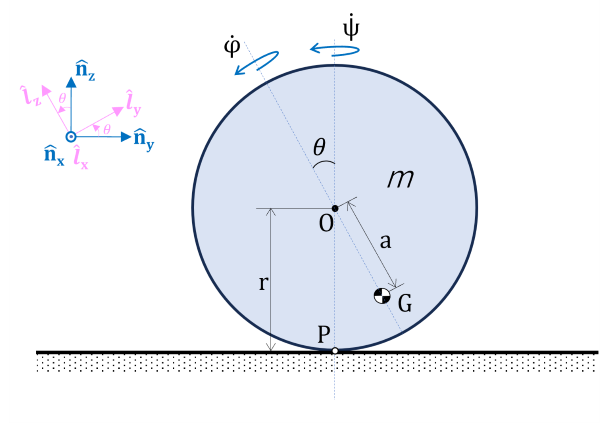

## Defining spherical top's geometry
The figure above shows a spherical top of radius $\text{r}$ and mass $\text{m}$ to be considered. Its center of mass $\text{G}$ is located below the geometric center $\text{O}$ with distance $\text{a}$. We are interested in the top's inversion, not translatinal movement, so the sphere's gemetric center is fixed in the space-fixed frame N to avoid gluts of sines and cosines with different Eulers angles. The sphere's contact point $\text{P}$ slips without rotation, giving rise to frictional force. The top's rotation will be descrived with reference frames  Y, L and R associated with each Euler angle ($\psi, \theta, \phi$) following the ZXZ convention. A lowercase bold letter with a hat represents a unit basis vector. (Examples: $\boldsymbol{\hat{n}_x}, \boldsymbol{\hat{n}_y}, \boldsymbol{\hat{n}_z}$)

In [ ]:
# top's mass, radius, length between mass center & geometric center and gravity acceleration
m, r, a, g = symbols('m r a g') 
# normal reaction force, frictional force and coefficient of friction
Kn, Kf, mu = symbols('K_n K_f mu') 
# principal moments of inertia of the top
A, C = symbols('A C' ) 
# define dynamic symbols to express Euler's angles together with 1st and 2nd time derivatives
# precession
psi = dynamicsymbols('psi')
psi_dot = dynamicsymbols('psi',1) 
psi_ddot = dynamicsymbols('psi',2)
# nutation
theta = dynamicsymbols('theta')
theta_dot = dynamicsymbols('theta',1) 
theta_ddot = dynamicsymbols('theta',2)
# spin
phi = dynamicsymbols('phi')
phi_dot = dynamicsymbols('phi',1) 
phi_ddot = dynamicsymbols('phi',2)
# reference frames given by an Euler ZXZ sequence
N = ReferenceFrame('N') # space-fixed frame
Y = N.orientnew('Y','Axis', (psi,N.z))
L = Y.orientnew('L', 'Axis', (theta,Y.x))
R = L.orientnew('R', 'Axis', (phi, L.z)) 
# defining the spherical top's geometry
P = Point('P') # top's contact point 
O = P.locatenew('O', r*N.z) # tops's center
G = O.locatenew('G', -a*L.z) # tops's center of mass
O.set_vel(N, 0) # top's geometric center is fixed in the space

## Deriving equations of motion
The sphere's mass center moves about the geometric center due to gravity and forces exerted on the sphere through the contact point. Its equation of motion is given by: 
$$m\frac{^N{d{\boldsymbol{V}_G}}}{dt} = \boldsymbol{K}_f + \boldsymbol{K}_n - mg\,\boldsymbol{\hat{n}}_z, \tag{1}$$
where $\boldsymbol{V}_G$ is mass center's velocity, "N" beside the time-derivative means that the derivative is done in the space-fixed frame, $\boldsymbol{K}_f$ is a frictional force and $\boldsymbol{K}_n$ a reactional one.

The angular momentum of the spherical top about its mass center $\boldsymbol{H}$ is given with its principal moments of inertia A, A and C by
$$
\boldsymbol{H} = A\omega_1\boldsymbol{\hat{l}_x} +A\omega_2\boldsymbol{\hat{l}_y}+C\omega_3\boldsymbol{\hat{l}_z},  \tag{2}
$$
where
$$
\begin{align}
\omega_1 =&\, \dot{\theta}\\
\omega_2 =&\, \sin\theta\,\dot{\psi}\\
\omega_3 =&\, \cos\theta\,\dot{\psi}+\dot{\phi}.\tag{3}\\
\end{align}
$$
Entering (3) into (2) we get the angular momentum of the top expressed in Euler angles
$$
\boldsymbol{H} = A\dot{\theta}\boldsymbol{\hat{l}_x} +A\sin\theta\,\dot{\psi}\boldsymbol{\hat{l}_y}+C(\cos\theta\dot{\psi}+\dot{\phi})\boldsymbol{\hat{l}_z},  \tag{4}
$$

In [ ]:
# define the intertia tensor of the sphere
J=inertia(L,A,A,C) 
# angular momentum of the body
H_ang_momt = J.dot(R.ang_vel_in(N)).express(L)
H_ang_momt

If we define $\boldsymbol{M}$ as external torque acting on the mass center through $\boldsymbol{P}$, the Euler's equation of motion is given by:
$$
\frac{^N{d{\boldsymbol{H}}}}{dt} = \boldsymbol{M} \tag{5}
$$
Next we will look at the right hand side of the equation - that is a torque about $\text{G}$ exerted by the forces on the contact point $\text{P}$

## Frictional force
Following the literature like A.C.Or (1994), we only consider viscous friction that yields an "exponential growth" compared to the Coulomb force that works algebraically. So, $\boldsymbol{K}_f$ is assumed propotional to $\boldsymbol{V}_P$ with a friction coefficient $\mu$ with the opposite sign. As we assumed there is no translational movment of the geometric center of the sphere $\boldsymbol{V}_P$ comes from rotation of the body only. Here we also assume that the inverting speed of the top is much slower than both spinning and precessing speeds, namely $\dot{\psi},\dot{\phi}\gg\dot{\theta} \simeq 0$, so the angular velocity of the body becomes
$$^N\boldsymbol{\Omega}^R = \dot{\psi}\,\boldsymbol{\hat{n}}_z+\dot{\phi}\,\boldsymbol{\hat{l}}_z, \tag{6}$$
meaning that the frictional force caused by the top's nutation is neglegible (See R.Cross(2018) for details). Then the contact point's velocity $\boldsymbol{V}_P$ is calculated as: 
$$
\begin{align}
\boldsymbol{V}_P =&\, ^N\boldsymbol{\Omega}^R \times \overrightarrow{\mathrm{GP}}\\
                 =&\, (\dot{\psi}\,\boldsymbol{\hat{n}}_z+\dot{\phi}\,\boldsymbol{\hat{l}}_z)
                 \times (a\,\boldsymbol{\hat{l}}_z - r\,\boldsymbol{\hat{n}}_z)\\
                 =&\,  (a\,\dot{\psi}+r\,\dot{\phi})\,\sin\theta\,\boldsymbol{\hat{l}}_x,\tag{7}
\end{align}
$$
 which goes only one direction.We have frictional force 
$$
\begin{align}
\boldsymbol{K}_f =& -\mu\boldsymbol{V}_P\\
                   =& -\mu(a\,\dot{\psi}+r\,\dot{\phi})\,\sin\theta\,\boldsymbol{\hat{l}}_x. \tag{8}\\
\end{align}
$$

In [ ]:
#contact point's velocity
Vp=(psi_dot*N.z+phi_dot*L.z).cross(a*L.z-r*N.z)
# frictional force
Kf_=(-mu*Vp).express(L).simplify()
Kf_

## Reactional force 
Next we calculate $\boldsymbol{K}_n$. Re-arrange (1) for $\boldsymbol{K}_n$. Considering its vetical componet we have:
$$
K_n \equiv \boldsymbol{K}_n\cdot \boldsymbol{\hat{n}}_z = m\frac{^N{d{\boldsymbol{V}_G}}}{dt}\cdot \boldsymbol{\hat{n}}_z+mg \tag{9}
$$


$\boldsymbol{V}_G$ is given by:
$$
\begin{align}
\boldsymbol{V}_G=&\,^N\boldsymbol{\Omega}^R\times \overrightarrow{\mathrm{OG}}\\
=&\, (\dot{\psi}\,\boldsymbol{\hat{n}}_z+\dot{\theta}\,\boldsymbol{\hat{y}}_x+\dot{\phi}\,\boldsymbol{\hat{l}}_z) \times (-a\,\boldsymbol{\hat{l}}_z)\\
=&\, -a\,\sin \theta\, \dot{\psi}\, \boldsymbol{\hat{l}}_x + a\,\dot{\theta}\, \boldsymbol{\hat{l}}_y. \tag{10}\\                
\end{align}
$$
Note that $\dot{\theta}$ remains in the equation so as to capture the movement of the mass center. 
From (8) and (9) we have
$$K_n=am(\sin\theta\,\ddot{\theta}+\cos\theta\,{\dot{\theta}}^2)+gm \tag{11}$$

In [ ]:
# mass center's velocity
VG=R.ang_vel_in(N).cross(-a*L.z) # G.v2pt_theory(O, N, L) will give the same result
# reactional force at the point P
Kn_=m*VG.dt(N).dot(N.z).simplify()+m*g
Kn_

Now the torque about the mass center arising from the forces acting on the point P is obtained as: 
$$
\begin{align}
\boldsymbol{M}=&\overrightarrow{\mathrm{GP}}\times \boldsymbol{K}\\
=& (a\,\boldsymbol{\hat{l}}_z - r\,\boldsymbol{\hat{n}}_z)\times (K_f\boldsymbol{\hat{l}}_x +K_n\boldsymbol{\hat{n}}_z)\\
=& -K_n\,a\,\sin\theta \boldsymbol{\hat{l}}_x+K_f(a-r\cos\theta)\boldsymbol{\hat{l}}_y +K_f\, r\sin\theta\boldsymbol{\hat{l}}_z.\tag{12}\\
\end{align}
$$

In [ ]:
# torque about the mass center caused by forces acting on the point P 
torq=((a*L.z-r*N.z).cross(Kf*L.x+Kn*N.z)).express(L).simplify()
torq

Entering (4) and (12) into (5), we have a system of three second-order differential equations: 
$$
\begin{equation}
\left\{ \,
    \begin{aligned}
    & A\ddot{\theta}-A\sin\theta\cos\theta{\dot{\psi}}^2 +C(\cos\theta\,\dot{\psi}+\dot{\phi})\sin\theta\dot{\psi}= - K_n\,a\,\sin\theta\\
    & A\sin\theta\,\ddot{\psi}+2A\cos\theta\,\dot{\psi}\dot{\theta}+C(\cos\theta\,\dot{\psi}+\dot{\phi})\dot{\theta} = K_f(a-r\cos\theta) \\
    & C(\ddot{\phi}+\cos\theta\,\ddot{\psi}-\sin\theta\,\dot{\psi}\,\dot{\theta}) = K_f\, r\sin\theta 
    \end{aligned}
\right. \tag{13}
\end{equation}
$$

Using (8) and (9), the equations in (13) are further expressed in the Euler angles and their time derivatives given in the Output below. 

In [ ]:
torq=torq.xreplace({Kn:Kn_,Kf:Kf_.dot(L.x)})
Eq=(H_ang_momt.dt(N)-torq).to_matrix(L)
Eq

## Numerical solution
The codes given below follow a standard procedure to numerically solve ordinary differential equaitons with odeint. 

In [ ]:
# the equations of motions are rearranged for the Euler angles' second order derivatives 
EOMs = solve([Eq[0],Eq[1],Eq[2]], (theta_ddot, psi_ddot, phi_ddot))
theta_ddot = EOMs[theta_ddot].trigsimp()
psi_ddot = EOMs[psi_ddot]
phi_ddot = EOMs[phi_ddot]

In [ ]:
#  same physical parameters as those given in Rutstam (2013) "Analysis of Dynamics of the tippe top"
_r = 0.02 # m
_a = 0.45*_r
_g = 9.81
_m= 0.02
_A = 2/5*_m*_r**2    #kg-m^2
_C = 2/5*_m*_r**2    #kg-m^2
_mu = 0.1
# substitute the "symbolic" parameters by numerical ones
_psi_ddot = psi_ddot.subs([(m,_m), (a,_a), (r,_r), (g,_g), (A,_A), (C,_C), (mu,_mu)])
_theta_ddot = theta_ddot.subs([(m,_m), (a,_a), (r,_r), (g,_g), (A,_A), (C,_C), (mu,_mu)])
_phi_ddot = phi_ddot.subs([(m,_m), (a,_a), (r,_r), (g,_g), (A,_A), (C,_C), (mu,_mu)])
args = (theta, psi_dot, theta_dot, phi_dot)
# lamdify the angular velocity expressed in the Euler angles for numerical calculation
z1d_f = lambdify(args, _psi_ddot, "numpy")
z2d_f = lambdify(args, _theta_ddot, "numpy")
z3d_f = lambdify(args, _phi_ddot, "numpy")
# Define a function for the odeint solver
def dSdt(S, t):
    _psi, z1, _theta, z2, _phi, z3 = S
    return [
        z1,
        z1d_f(_theta, z1, z2, z3),
        z2,
        z2d_f(_theta, z1, z2, z3),
        z3,
        z3d_f(_theta, z1, z2, z3),
    ]

In [ ]:
#Initial conditions
psi_dot0 = 0.0           # rad/s
theta_dot0 = 0.0         # rad/s
phi_dot0 = 155.0         # rad/s
psi_0 = 0.0              # rad
theta_0 = 0.2            # rad
phi_0 = 0.0              # rad
y0=[psi_0, psi_dot0, theta_0, theta_dot0, phi_0, phi_dot0]
# Simulation parameters:
n_smp = 800
t_bgn = 0.0
t_end = 2.5
t = np.linspace(t_bgn, t_end, n_smp)
# Numerically integrate the equations of motion
ans = odeint(dSdt, y0=y0, t=t)
# Extract the results:
psi_t = ans.T[0]
the_t = ans.T[2]
phi_t = ans.T[4]

## 3D Modelling and animating a tippe top in Vpython

For the sake of visualization, easier for viewers to see the top's inverting movement, instead of a sphere, a tuncated sphere with a stem was modelled with Vpython. The Tippe top model is composed of three parts: a truncated sphere, stem and tip end - to be "compounded" together. Modelling a truncated sphere followed the "extrusions" example given at Vpython's site:
https://www.glowscript.org/#/user/GlowScriptDemos/folder/Examples/
Please note that the X,Y,Z axes and their directions in Vpython's display do not match what I gave in the codes, so that I had to manually adjust the values on a try and error basis.

In [ ]:
# Setting the scene
scene = vp.canvas()
scene.width = 640
scene.height = 480
scene.center=vp.vec(0,0.5,0)
scene.range = 3.2

# parameters for the 3D model
r1 = 1  # sphere's radius
r2 =0.2 # stem's radius
N = 30 # No. of points to draw a truncated circle hem
x_sft=-3 # x-coordinate of the basis vecto's origin
y_sft=-1 # y-coordinate of the basis vecto's origin

# defining a truncated sphere, stem and tip 
th0=vp.pi/6
ths=np.linspace(0,vp.pi/2+th0,N)
scalef = []
hpath = []
scene.visible = True 
for th in ths:
    x = r1*vp.cos(th)
    rad = vp.sqrt(r1**2 - x**2)
    scalef.append(rad)
    hpath.append(vp.vec(x,0,0))
hem = vp.extrusion(path=hpath, shape=vp.shapes.circle(radius=r1), scale=scalef,
      show_start_face = False, color=vp.color.gray(0.8) )
stem = vp.cylinder(pos=vp.vec(0,0,0), axis = vp.vec(-r1+r2,0,0) ,color=hem.color, radius=r2)
tip = vp.sphere(pos=vp.vec(-r1+r2,0,0), color=hem.color, radius=r2)

# all three pars are compounded as one component
tippe = vp.compound([hem, stem, tip ]) # comprising 
tippe.axis = vp.vec(0,-1,0)
tippe_center = tippe.pos
tippe.texture = vp.textures.metal

for i in range(n_smp):
    vp.rate(30) 
    # setting a rotational axis about the stem of the top
    tippe.axis = tippe.length*vp.vector(vp.sin(the_t[i])*vp.sin(psi_t[i]),-vp.cos(the_t[i]),vp.sin(the_t[i])*vp.cos(psi_t[i]))
    # rotate the top about its stem
    tippe.rotate(angle=phi_t[i])

## References

A.C. Or. (1994) "The Dynamics of a Tippe Top" SIAM Journal on Applied Mathematics, 54 (3), pp.597-609.

Rod Cross (2018) "Dynamics of a spherical tippe top," Eur. J. Phys.39 035001 https://doi.org/10.1088/1361-6404/aaa34f

N Rutstam (2013) "Analysis of dynamics of the tippe top" https://www.diva-portal.org/smash/get/diva2:602220/FULLTEXT01.pdf

江沢洋, 中村孔一, 山本義隆 (著) 　演習詳解　力学　第２版 (ちくま学芸文庫) ISBN-13: 978-4480511188
